In [2]:
import sys
print(sys.executable)

c:\Users\HP\OneDrive\Desktop\Python\python.exe


In [3]:
%pip install seaborn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Customer Retention Intelligence Platform

## Exploratory Data Analysis (EDA)

Author: Zahid Shaikh

Dataset: Customer Churn Dataset

Project Goal:
Analyze customer behavior, identify churn patterns, and generate business insights using Python.

In [6]:
print("Rows and Columns:", df.shape)

Rows and Columns: (7032, 21)


In [7]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [14]:
df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7022,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7023,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7024,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.10,No
7025,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.30,No
7026,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7031,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


In [15]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6168,1260-TTRXI,Male,0,No,No,4,Yes,No,DSL,No,...,No,No,No,Yes,Month-to-month,No,Electronic check,54.30,195.30,Yes
5877,1709-EJDOX,Female,0,Yes,Yes,47,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.75,948.90,No
1717,9060-HJJRW,Female,0,No,No,51,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),56.40,2928.50,No
6266,0885-HMGPY,Male,0,No,No,62,Yes,Yes,DSL,Yes,...,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),69.40,4237.50,No
3795,5914-DVBWJ,Female,1,No,No,18,Yes,Yes,Fiber optic,No,...,No,Yes,No,No,Month-to-month,Yes,Electronic check,85.45,1505.85,Yes
3165,7272-QDCKA,Male,0,No,No,28,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,One year,No,Electronic check,100.20,2688.45,No
723,5244-IRFIH,Male,1,Yes,No,33,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.50,3105.55,Yes
3594,8623-TMRBY,Male,1,Yes,Yes,51,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,84.20,4146.05,Yes
4952,7480-QNVZJ,Male,1,No,No,50,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.70,4816.70,Yes
6980,3585-ISXZP,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),95.65,778.10,Yes


In [16]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

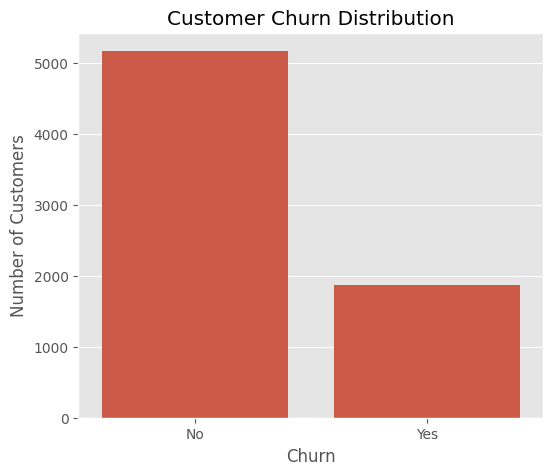

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/churn_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

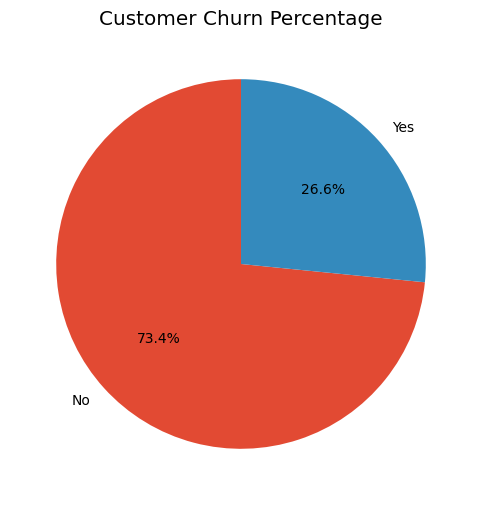

In [25]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Customer Churn Percentage")

plt.savefig("../reports/figures/churn_percentage.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [20]:
import os

print(os.getcwd())

c:\Users\HP\OneDrive\Desktop\Projects\Customer-Retention-Intelligence-Platform\notebooks


In [23]:
import os

print("Current Folder:", os.getcwd())
print("Reports exists:", os.path.exists("../reports"))
print("Figures exists:", os.path.exists("../reports/figures"))

Current Folder: c:\Users\HP\OneDrive\Desktop\Projects\Customer-Retention-Intelligence-Platform\notebooks
Reports exists: True
Figures exists: True


## Gender Analysis

In [26]:
df["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

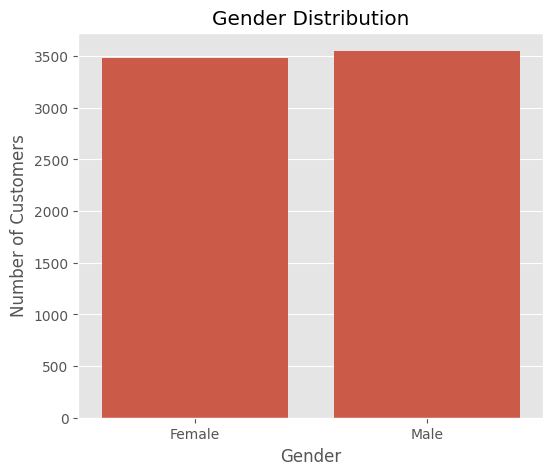

In [28]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/gender_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

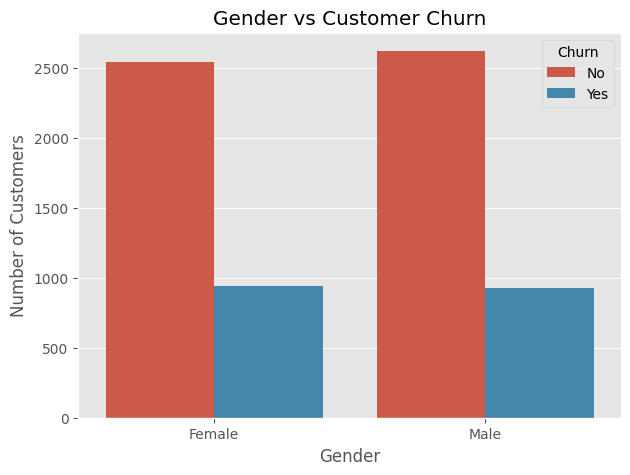

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="gender",
              hue="Churn")

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/gender_vs_churn.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### Insight

- Compare churn between male and female customers.
- Observe whether one gender has a noticeably higher churn rate.
- If the bars are similar, gender is likely not a strong predictor of churn.

## Senior Citizen Analysis

In [31]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

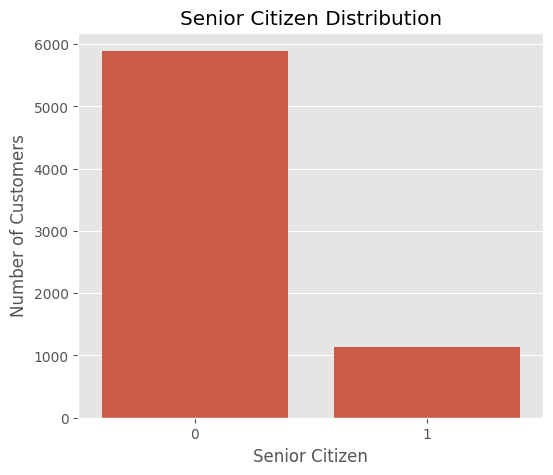

In [32]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="SeniorCitizen")

plt.title("Senior Citizen Distribution")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/senior_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

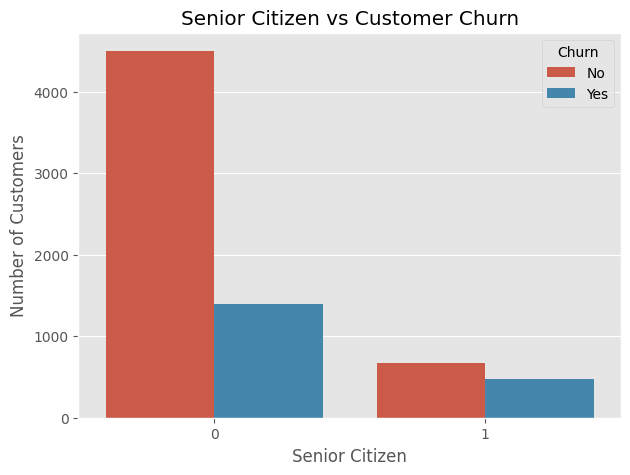

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="SeniorCitizen",
              hue="Churn")

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/senior_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Partner Analysis

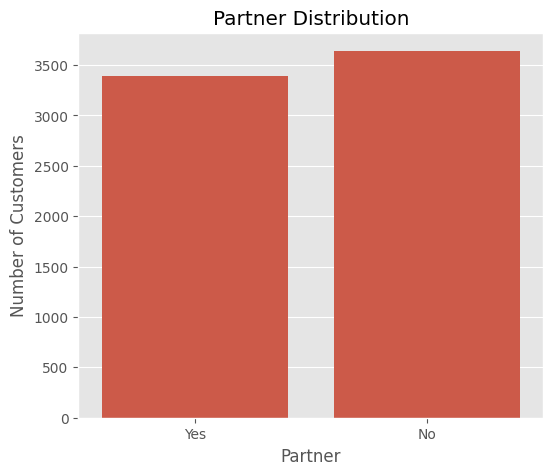

In [34]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Partner")

plt.title("Partner Distribution")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/partner_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

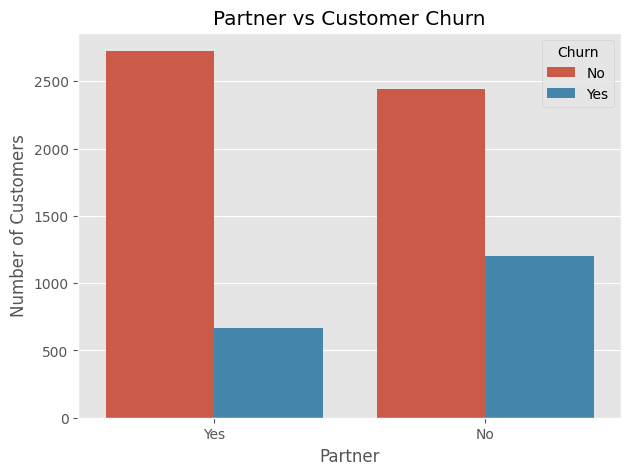

In [35]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="Partner",
              hue="Churn")

plt.title("Partner vs Customer Churn")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/partner_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Business Insight

Customers without partners may exhibit different churn behavior compared to customers with partners. Compare the churn counts to determine whether relationship status influences customer retention.

## Dependents Analysis

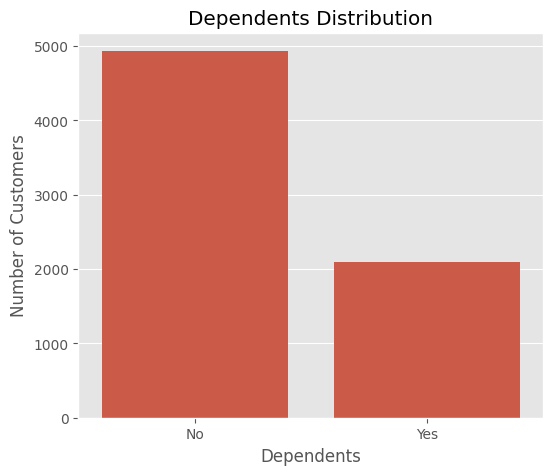

In [36]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="Dependents")

plt.title("Dependents Distribution")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/dependents_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

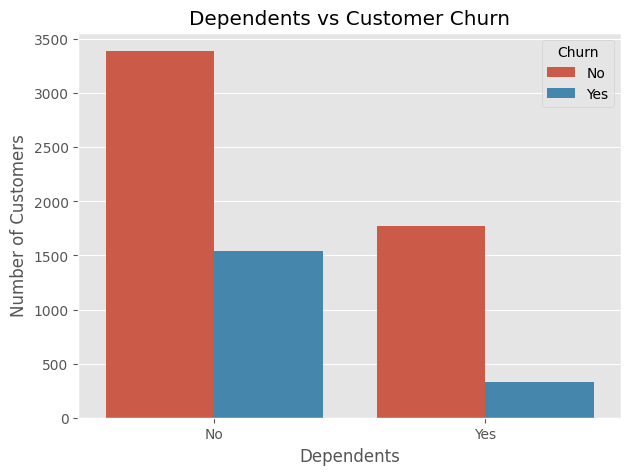

In [37]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="Dependents",
              hue="Churn")

plt.title("Dependents vs Customer Churn")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/dependents_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Business Insight

Analyze whether customers with dependents are less likely to churn. This insight can help identify family-oriented customer segments with stronger retention.

# Contract Analysis

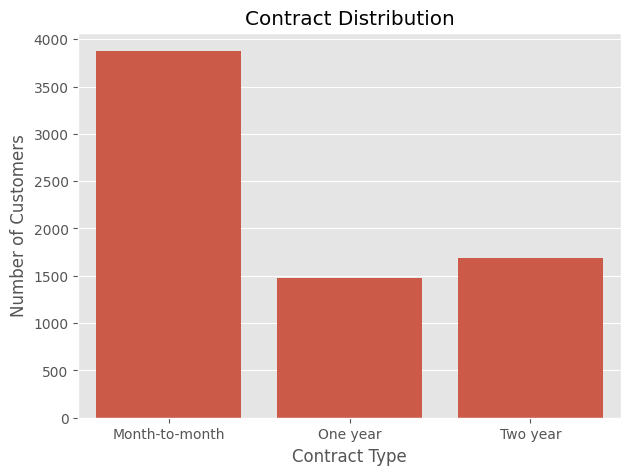

In [38]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Contract")

plt.title("Contract Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/contract_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

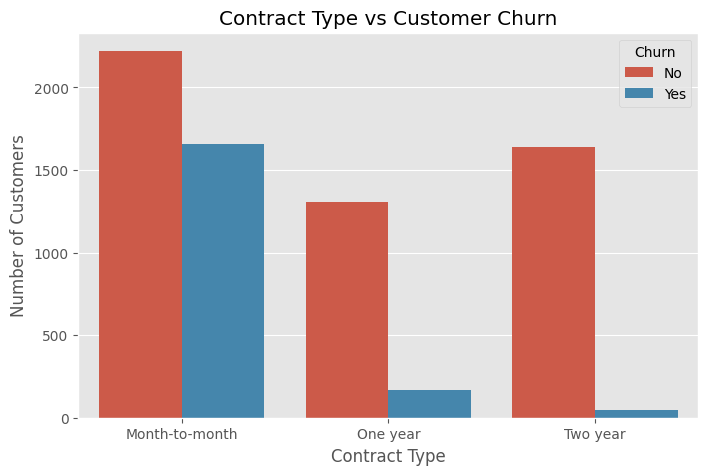

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/contract_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Business Insight

- Compare churn across Month-to-month, One year, and Two year contracts.
- Identify which contract type experiences the highest customer churn.
- Discuss how longer-term contracts influence customer retention.

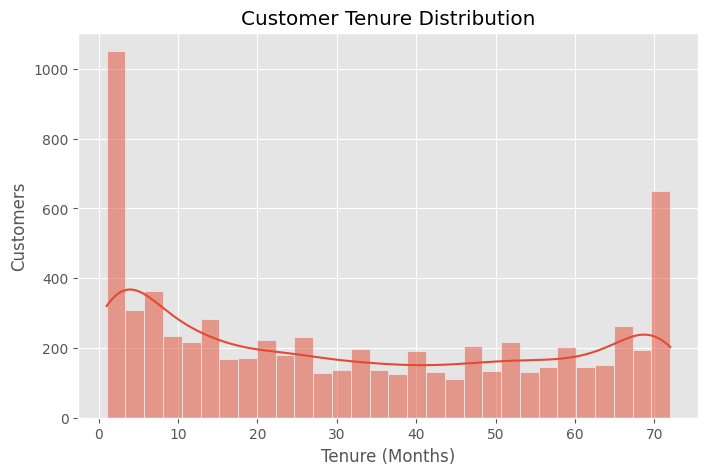

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customers")

plt.savefig("../reports/figures/tenure_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

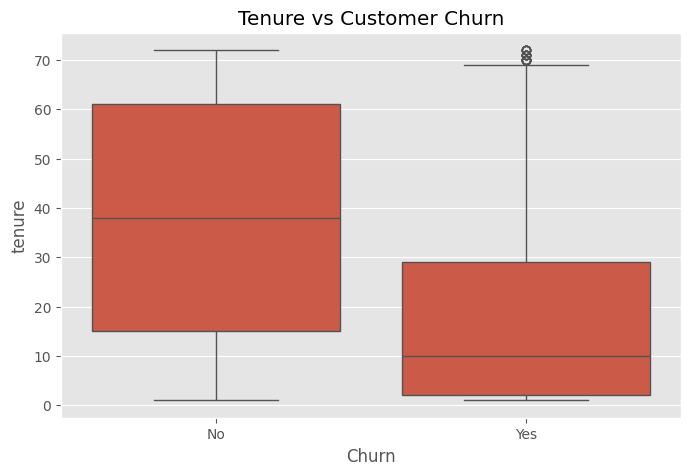

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Customer Churn")

plt.savefig("../reports/figures/tenure_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

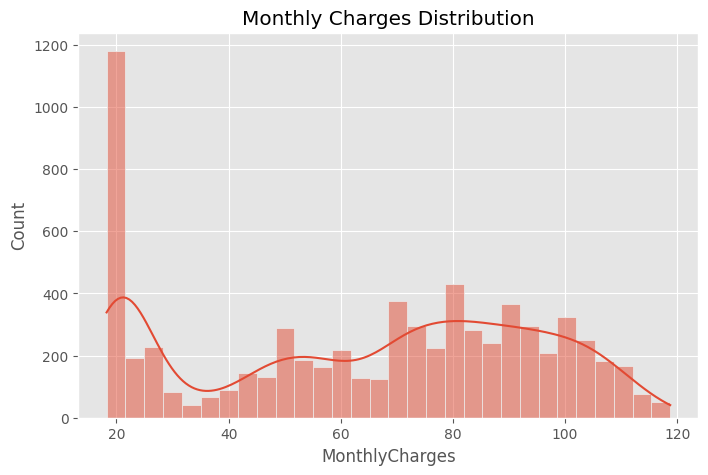

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Monthly Charges Distribution")

plt.savefig("../reports/figures/monthly_charges_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

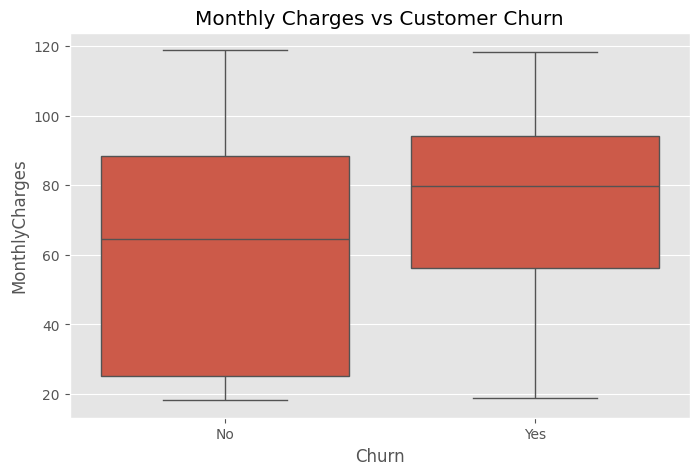

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Customer Churn")

plt.savefig("../reports/figures/monthly_charges_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

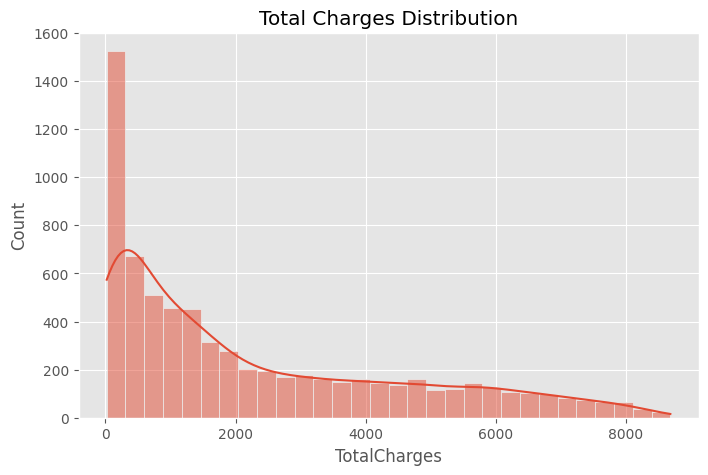

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(df["TotalCharges"], bins=30, kde=True)

plt.title("Total Charges Distribution")

plt.savefig("../reports/figures/total_charges_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Service Analysis

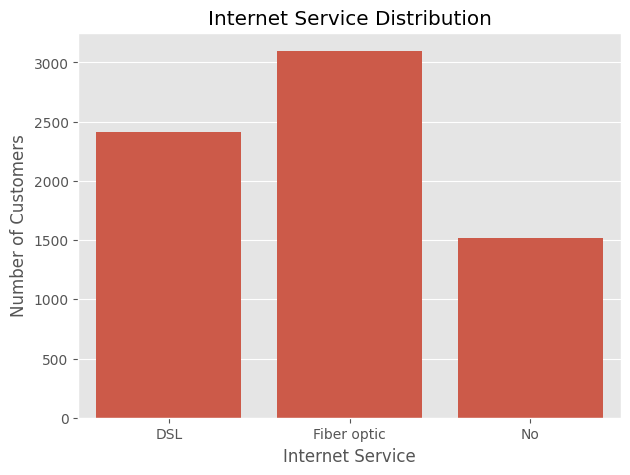

In [45]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="InternetService")

plt.title("Internet Service Distribution")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.savefig("../reports/figures/internet_service_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

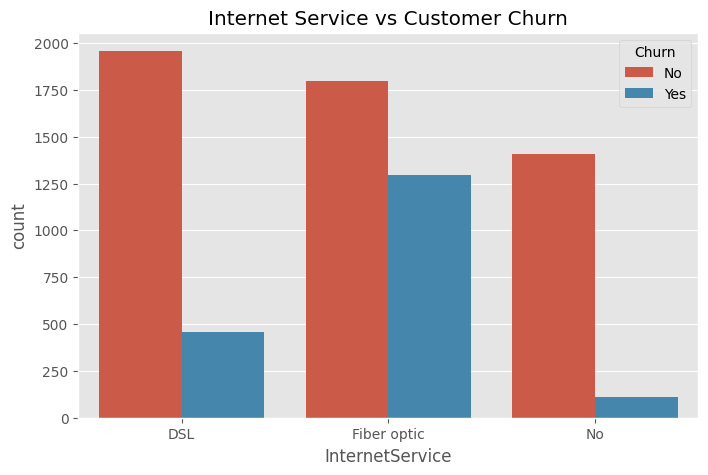

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Customer Churn")

plt.savefig("../reports/figures/internet_service_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

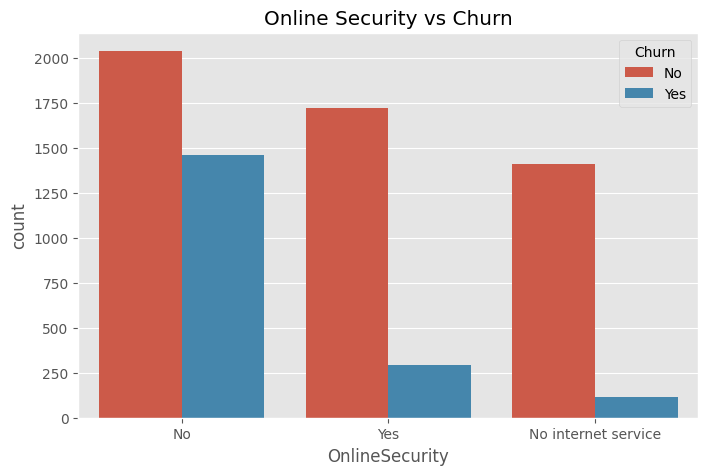

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)

plt.title("Online Security vs Churn")

plt.savefig("../reports/figures/online_security_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

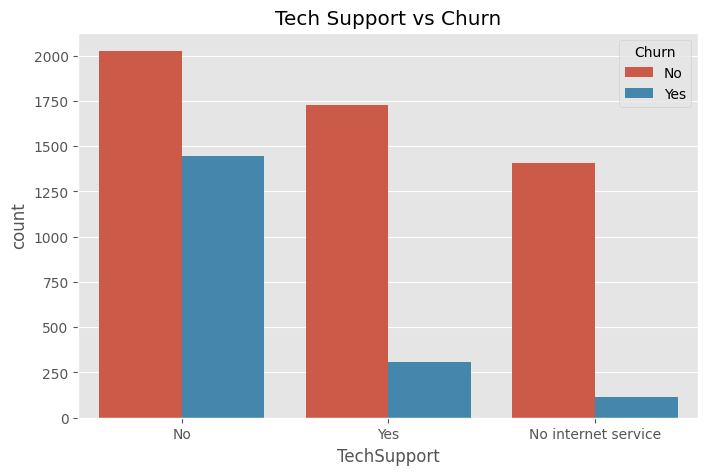

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Tech Support vs Churn")

plt.savefig("../reports/figures/tech_support_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

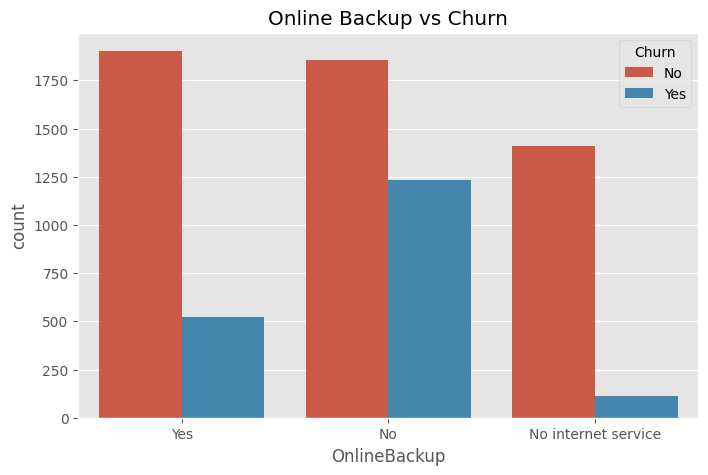

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="OnlineBackup",
    hue="Churn"
)

plt.title("Online Backup vs Churn")

plt.savefig("../reports/figures/online_backup_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

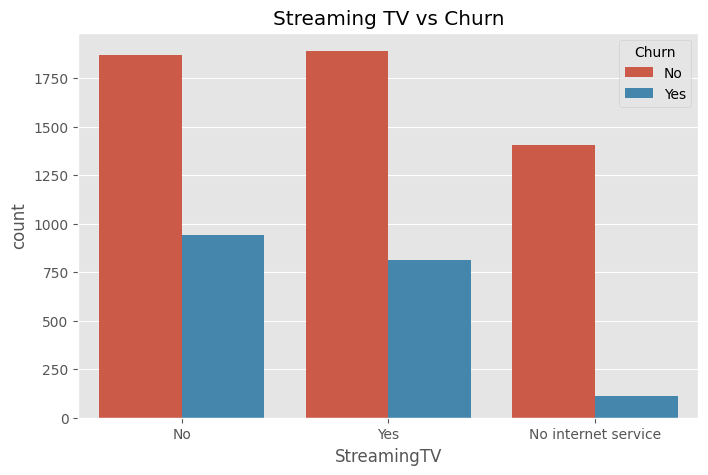

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="StreamingTV",
    hue="Churn"
)

plt.title("Streaming TV vs Churn")

plt.savefig("../reports/figures/streaming_tv_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

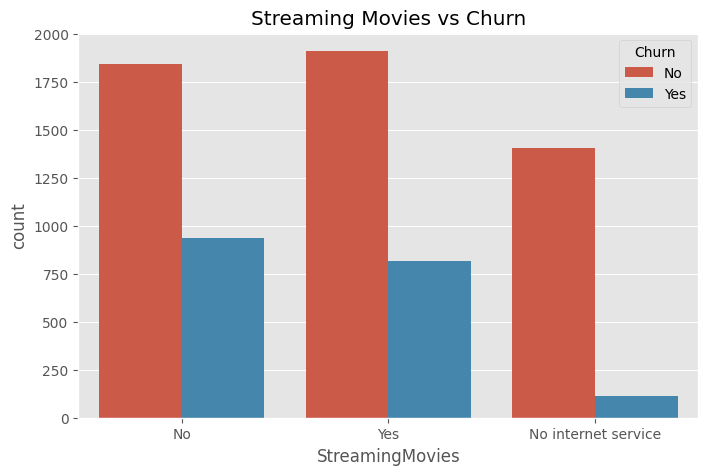

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="StreamingMovies",
    hue="Churn"
)

plt.title("Streaming Movies vs Churn")

plt.savefig("../reports/figures/streaming_movies_vs_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

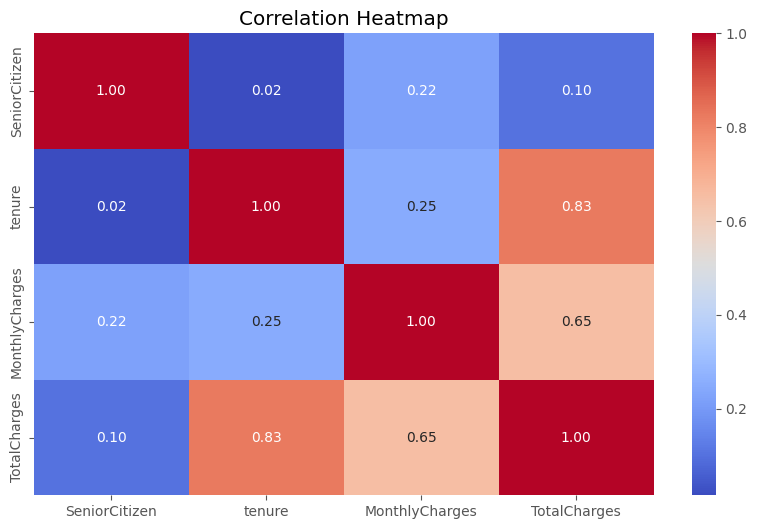

In [52]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("../reports/figures/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Business Insights

## Key Findings

### Customer Demographics
- Analyze whether gender, partner status, and dependents influence churn.
- Evaluate the churn rate among senior citizens.

### Contract Analysis
- Identify which contract type has the highest churn.
- Assess whether longer contracts improve retention.

### Financial Analysis
- Compare monthly charges between churned and retained customers.
- Examine the relationship between tenure and churn.

### Service Analysis
- Determine whether Online Security, Tech Support, or Online Backup reduce churn.
- Evaluate the impact of Internet Service type on customer retention.

## Recommendations

- Encourage customers to switch from month-to-month to longer-term contracts.
- Promote value-added services such as Online Security and Tech Support.
- Identify high-risk customer groups for proactive retention campaigns.